In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Any matrix into Idneitity matrix = Matrix
 # A * I = A

A = np.array([[2, 3],
              [4, 5]])

I = np.eye(2)   # 2x2 identity matrix
print("Identity:\n", I)

print("\nA @ I:\n", A @ I)
print("\nI @ A:\n", I @ A)

print("\nA @ I equals A?", np.array_equal(A @ I, A))
print("I @ A equals A?", np.array_equal(I @ A, A))

Identity:
 [[1. 0.]
 [0. 1.]]

A @ I:
 [[2. 3.]
 [4. 5.]]

I @ A:
 [[2. 3.]
 [4. 5.]]

A @ I equals A? True
I @ A equals A? True


In [4]:
# Compute determinant of the matrix

M1 = np.array([[1, 2], [3, 4]])
M2 = np.array([[3, 0], [0, 2]])
M3 = np.array([[1, 2], [2, 4]])
M4 = np.array([[0, -1], [1, 0]])

for name, M in [("M1", M1), ("M2", M2), ("M3", M3), ("M4", M4)]:
    det = np.linalg.det(M)
    print(f"det({name}) = {det:.4f}")

det(M1) = -2.0000
det(M2) = 6.0000
det(M3) = 0.0000
det(M4) = 1.0000


In [5]:
# Compute inverse of a matrix

A = np.array([[2, 1],
              [1, 1]])

A_inv = np.linalg.inv(A)
print("A:\n", A)
print("\nA⁻¹:\n", A_inv)

A:
 [[2 1]
 [1 1]]

A⁻¹:
 [[ 1. -1.]
 [-1.  2.]]


In [6]:
# Verify A * A⁻¹ = I

product = A @ A_inv
print("A @ A⁻¹:\n", product)
print("\nClose to identity?", np.allclose(product, np.eye(2)))

A @ A⁻¹:
 [[1. 0.]
 [0. 1.]]

Close to identity? True


In [10]:
M3 = np.array([[1, 2],
               [2, 4]])

# Zero determinant → matrix is singular → cannot be inverted
print("Det of M3 :", np.linalg.det(M3))


# Rank < matrix dimension → rank deficient → confirms no inverse exists
print("Rank of M3 :", np.linalg.matrix_rank(M3))


try:
    M3_inv = np.linalg.inv(M3)
    print("Inverse:\n", M3_inv)
except np.linalg.LinAlgError as e:
    print("Error:", e)

Det of M3 : 0.0
Rank of M3 : 1
Error: Singular matrix


In [11]:
T = np.array([[2, 0],
              [0, 3]])

# Unit square corners (each as a column for matrix multiplication)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]])

transformed = T @ square
print("Original corners:\n", square)
print("\nTransformed corners:\n", transformed)

print(f"\nDeterminant of T: {np.linalg.det(T):.4f}")
print(f"Expected area:    {2 * 3}")

Original corners:
 [[0 1 1 0]
 [0 0 1 1]]

Transformed corners:
 [[0 2 2 0]
 [0 0 3 3]]

Determinant of T: 6.0000
Expected area:    6


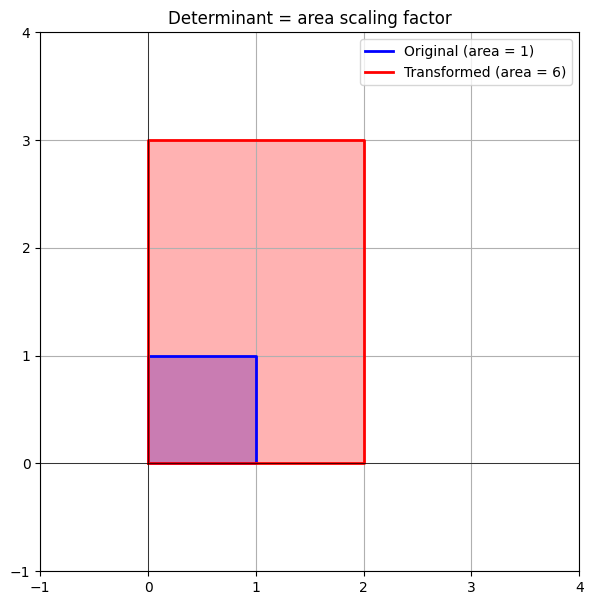

In [12]:
def plot_square(corners, color, label, ax):
    # Close the shape by appending first corner at the end
    x = np.append(corners[0], corners[0][0])
    y = np.append(corners[1], corners[1][0])
    ax.fill(x, y, color=color, alpha=0.3)
    ax.plot(x, y, color=color, linewidth=2, label=label)

fig, ax = plt.subplots(figsize=(7, 7))
plot_square(square, 'blue', 'Original (area = 1)', ax)
plot_square(transformed, 'red', 'Transformed (area = 6)', ax)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.grid(True)
ax.legend()
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)
ax.set_title('Determinant = area scaling factor')
plt.show()

det(F) = -1.0000


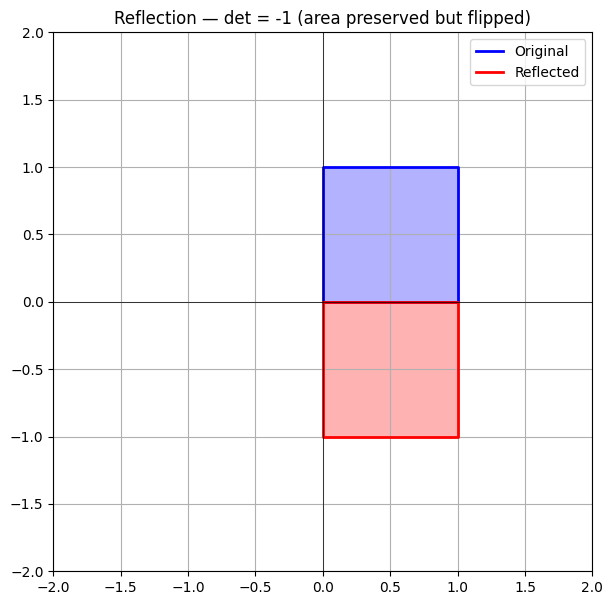

In [13]:
# Reflection across the x-axis
F = np.array([[1,  0],
              [0, -1]])

print(f"det(F) = {np.linalg.det(F):.4f}")

reflected = F @ square

fig, ax = plt.subplots(figsize=(7, 7))
plot_square(square, 'blue', 'Original', ax)
plot_square(reflected, 'red', 'Reflected', ax)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.grid(True)
ax.legend()
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_title('Reflection — det = -1 (area preserved but flipped)')
plt.show()

det(S) = 0.0000

Transformed corners:
 [[0 1 3 2]
 [0 2 6 4]]


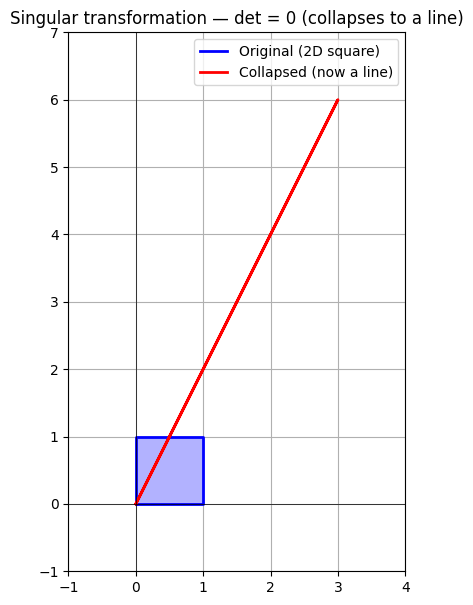

In [14]:
# Singular matrix — squishes everything onto a line
S = np.array([[1, 2],
              [2, 4]])

print(f"det(S) = {np.linalg.det(S):.4f}")

collapsed = S @ square
print("\nTransformed corners:\n", collapsed)

fig, ax = plt.subplots(figsize=(7, 7))
plot_square(square, 'blue', 'Original (2D square)', ax)
plot_square(collapsed, 'red', 'Collapsed (now a line)', ax)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.grid(True)
ax.legend()
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 7)
ax.set_title('Singular transformation — det = 0 (collapses to a line)')
plt.show()

In [15]:
# The concept of detemrinant and invertibility is used in conjuction to identify the unique solutions 
# to system of equations


# ============================================================
# CASE A — INVERTIBLE MATRIX (unique solution exists)
# ============================================================

# We want to solve: A @ x = b
# This is asking: "What vector x, when transformed by A, gives b?"
A = np.array([[2, 1],
              [1, 3]])

b = np.array([5, 10])

# Step 1: Check the determinant
# If det(A) ≠ 0, A is invertible → unique solution exists
# If det(A) = 0, A is singular → no unique solution
det = np.linalg.det(A)
print(f"det(A) = {det:.4f}")

# Step 2: Decide whether to solve
# We don't compare det to 0 directly because of floating-point errors
# (a "zero" determinant might compute as 1e-16 instead of exactly 0)
# Instead, check if it's larger than a tiny tolerance
if abs(det) > 1e-10:
    # np.linalg.solve(A, b) internally computes x = A⁻¹ @ b
    # but it does so more efficiently and stably than directly inverting A
    x = np.linalg.solve(A, b)
    print(f"Unique solution: x = {x}")
    
    # Sanity check: A @ x should equal b
    print(f"Verify A @ x = {A @ x}")
    print(f"Original b    = {b}")
else:
    print("Matrix is singular — no unique solution.")


# ============================================================
# CASE B — SINGULAR MATRIX (no unique solution)
# ============================================================

# This matrix is singular because row 2 = 2 × row 1
# Geometrically, it collapses 2D space onto a single line
A_singular = np.array([[1, 2],
                       [2, 4]])

print(f"\ndet(A_singular) = {np.linalg.det(A_singular):.4f}")
print(f"Rank of A_singular = {np.linalg.matrix_rank(A_singular)}")
# rank = 1 (not 2) confirms it's rank-deficient

# Try to solve — this will fail
try:
    x = np.linalg.solve(A_singular, b)
    print(f"Solution: x = {x}")
except np.linalg.LinAlgError as e:
    # np.linalg.LinAlgError is the specific exception numpy raises
    # for linear algebra failures (singular matrix, ill-conditioned, etc.)
    print(f"Cannot solve: {e}")

det(A) = 5.0000
Unique solution: x = [1. 3.]
Verify A @ x = [ 5. 10.]
Original b    = [ 5 10]

det(A_singular) = 0.0000
Rank of A_singular = 1
Cannot solve: Singular matrix


In [16]:

# ============================================================
# BACKGROUND: WHAT IS A COVARIANCE MATRIX?
# ============================================================
#
# A covariance matrix measures how multiple variables vary together.
# For 3 stocks, it's a 3x3 grid:
#
#         AAPL    MSFT    JPM
# AAPL  [ var    cov     cov ]
# MSFT  [ cov    var     cov ]
# JPM   [ cov    cov     var ]
#
# - Diagonal entries (var): how volatile each stock is on its own
# - Off-diagonal (cov):     how pairs of stocks move together
#     - Positive → they tend to move in the same direction
#     - Negative → they tend to move in opposite directions
#     - Zero     → they move independently
#
# This will be covered formally in Block 3 (Probability & Statistics).
# For today, treat it as just "a matrix that comes up in real quant work."
#
# CONNECTION TO TODAY'S TOPIC:
# A valid covariance matrix must be invertible. If two assets are 
# perfectly correlated (one is a scalar multiple of the other), the 
# matrix becomes singular (det = 0, rank-deficient). This is the same 
# concept as today's lesson — just applied to a real-world matrix.


# ============================================================
# STEP 1 — SIMULATE STOCK RETURNS
# ============================================================
# 5 days of daily returns for 3 stocks.
# Stock C is created as a copy of Stock A, meaning they're 
# perfectly correlated (no independent information from Stock C).

np.random.seed(42)
stock_a = np.random.normal(0, 0.01, 5)   # Stock A: random returns
stock_b = np.random.normal(0, 0.01, 5)   # Stock B: independent of A
stock_c = stock_a.copy()                  # Stock C = Stock A (identical)

# Stack as columns: rows = days, cols = stocks
# Shape (5, 3) — 5 days, 3 stocks
returns = np.column_stack([stock_a, stock_b, stock_c])
print("Returns matrix shape:", returns.shape)
print("Returns:\n", returns)


# ============================================================
# STEP 2 — COMPUTE THE COVARIANCE MATRIX
# ============================================================
# np.cov computes the covariance between columns of the input.
# rowvar=False tells numpy "each COLUMN is a variable" 
# (which matches our convention: rows = samples, cols = features).
#
# Without rowvar=False, numpy assumes rows are variables — which 
# would be wrong here.

cov = np.cov(returns, rowvar=False)

print("\nCovariance matrix (3x3):")
print(cov)
print("\nShape of cov:", cov.shape)


# ============================================================
# STEP 3 — CHECK IF THE COVARIANCE MATRIX IS INVERTIBLE
# ============================================================
# Apply today's lesson:
# - det = 0  → matrix is singular → has redundant info
# - rank < dimension → confirms rank-deficiency

det = np.linalg.det(cov)
rank = np.linalg.matrix_rank(cov)

print(f"\ndet(cov) = {det:.6e}")     # scientific notation; we expect ~0
print(f"Rank of cov = {rank}")        # we expect 2, not 3

# Interpretation:
# - det ≈ 0 confirms the matrix is singular
# - Rank = 2 (not 3) confirms one stock carries no new information


# ============================================================
# STEP 4 — TRY TO INVERT IT (THIS WILL FAIL)
# ============================================================
# In real portfolio optimization (Markowitz, Sharpe ratio calc, etc.)
# the covariance matrix needs to be inverted. A singular matrix
# breaks these algorithms.

try:
    cov_inv = np.linalg.inv(cov)
    print("Inverse:\n", cov_inv)
except np.linalg.LinAlgError as e:
    print(f"\nCannot invert covariance matrix: {e}")


# ============================================================
# WHAT THIS TELLS YOU IN PRACTICE
# ============================================================
# In a real fund, before running any portfolio optimization, you'd
# check the covariance matrix's determinant. If it's near zero:
#
# 1. You have perfectly (or near-perfectly) correlated assets
# 2. Your "diversification" is an illusion — you're really holding
#    fewer independent bets than the number of tickers suggests
# 3. Standard optimization routines will fail or produce garbage
#
# Fixes used in practice (you'll learn these later):
# - Drop redundant assets
# - Add "regularization" (a tiny constant to the diagonal to make 
#   it invertible)
# - Use robust methods that handle singular matrices gracefully

Returns matrix shape: (5, 3)
Returns:
 [[ 0.00496714 -0.00234137  0.00496714]
 [-0.00138264  0.01579213 -0.00138264]
 [ 0.00647689  0.00767435  0.00647689]
 [ 0.0152303  -0.00469474  0.0152303 ]
 [-0.00234153  0.0054256  -0.00234153]]

Covariance matrix (3x3):
[[ 5.01592876e-05 -4.20712542e-05  5.01592876e-05]
 [-4.20712542e-05  6.74275176e-05 -4.20712542e-05]
 [ 5.01592876e-05 -4.20712542e-05  5.01592876e-05]]

Shape of cov: (3, 3)

det(cov) = 0.000000e+00
Rank of cov = 2

Cannot invert covariance matrix: Singular matrix
